In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import xarray as xr
import scipy.io as sio
from datetime import datetime, timedelta

import sys
sys.path.append("functions") 
from functions import solo, project_sadcp_to_transect, translate_solo_results, axis_ratio_from_Q, tangential_velocity, out_core_param_fit, model_uv_at_xy, vector_R2 


### Projecting data onto straight-line

### SADCP Data

In [2]:
sad = sio.loadmat('data/sadcp_data.mat', simplify_cells=True)

z = sad['z_sadcp']
ref = datetime(2000,1,1,12)
time = np.array([ref + timedelta(days=jd-2451545.0) for jd in sad['tim_sadcp']], dtype='datetime64[ns]')

df = pd.DataFrame({
    "Time": time,
    "Lon": sad['lon_sadcp'],
    "Lat": sad['lat_sadcp']
})

df = pd.concat([
    df,
    pd.DataFrame(sad['u_sadcp'], index=[f'u_{zv}' for zv in z]).T,
    pd.DataFrame(sad['v_sadcp'], index=[f'v_{zv}' for zv in z]).T
], axis=1)

df = df[df.Lat <= -37].reset_index(drop=True)

theta_mean, phi_mean = 154.3, -37.9
df["x"] = (df.Lon-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
df["y"] = (df.Lat-phi_mean)*111000

ds_sadcp = xr.Dataset(
    {"u": (("time","z"), df[[f"u_{zz}" for zz in z]].to_numpy()),
     "v": (("time","z"), df[[f"v_{zz}" for zz in z]].to_numpy())},
    coords={
        "time": df.Time.values,
        "z": z,
        "lon": ("time", df.Lon.values),
        "lat": ("time", df.Lat.values),
        "x": ("time", df.x.values),
        "y": ("time", df.y.values),
    }
)

# Transect slice
# Ex1 Good horizotnal Example
# t0 = pd.Timestamp("2023-10-20 13:30:00") 
# dt = pd.Timedelta(days=0.5)

# Ex2 Good vertical
t0 = pd.Timestamp("2023-10-18 01:30:00") 
dt = pd.Timedelta(days=0.5)

# Ex3 horizontal non-symmetric
# t0 = pd.Timestamp("2023-10-21 7:00:00")
# dt = pd.Timedelta(days=0.2)

# Ex4 vertical non-symmetric
# t0 = pd.Timestamp("2023-10-21 19:15:00")
# dt = pd.Timedelta(days=0.2)

# Ex5
# t0 = pd.Timestamp("2023-10-18 23:15:00")
# dt = pd.Timedelta(days=0.2)

ds_sadcp = ds_sadcp.sel(time=(ds_sadcp.time >= t0-dt) & (ds_sadcp.time <= t0+dt)).sel(z=37, method="nearest")
ds_sadcp


<xarray.Dataset> Size: 5kB
Dimensions:  (time: 96)
Coordinates:
  * time     (time) datetime64[ns] 768B 2023-10-17T13:42:30.666659 ... 2023-1...
    z        uint16 2B 37
    lon      (time) float64 768B 154.4 154.4 154.4 154.4 ... 154.5 154.5 154.5
    lat      (time) float64 768B -37.1 -37.1 -37.1 ... -38.76 -38.76 -38.76
    x        (time) float64 768B 7.198e+03 7.399e+03 ... 1.985e+04 1.968e+04
    y        (time) float64 768B 8.831e+04 8.833e+04 ... -9.562e+04 -9.556e+04
Data variables:
    u        (time) float64 768B 0.3383 0.3354 0.3216 ... -0.2969 -0.2948
    v        (time) float64 768B -0.06571 -0.03258 -0.06304 ... 0.006335 0.02006

### Satellite Data

In [3]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data
t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)
u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)
ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")
ds_sat = ds.interp(time=t6am)
# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)
# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))
# Transect time slice
ds_sat = ds_sat.sel(time=t0, method="nearest")
ds_sat


<xarray.Dataset> Size: 63kB
Dimensions:    (lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
    time       datetime64[ns] 8B 2023-10-19T06:00:00
Data variables:
    u          (lat, lon) float64 15kB -0.165 -0.2501 -0.3148 ... 0.2204 0.1816
    v          (lat, lon) float64 15kB -0.1421 -0.1373 ... -0.4873 -0.4257
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

### Approximate ESP parameters using SOLO

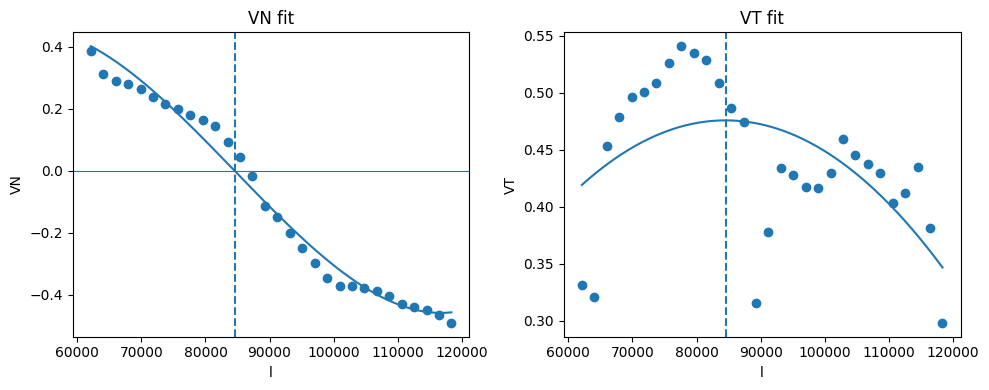

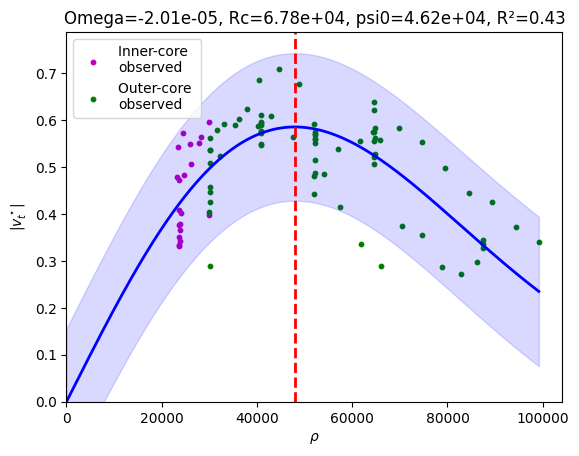

In [4]:
xi, yi, ui, vi = ds_sadcp.x.values, ds_sadcp.y.values, ds_sadcp.u.values, ds_sadcp.v.values

# Project data to transect
df_proj, moca_meta = project_sadcp_to_transect(xi, yi, ui, vi)
# Calculate core ESP parameters
l0, r0, w, Q, Omega = solo(df_proj.l, df_proj.V_T, df_proj.V_N, plot=True)
# Convert transect center coordinates (l0: length along transect, r0: length perpendicular to transect)
# to cartesian coordinates xc, yc
xc, yc = translate_solo_results(df_proj.iloc[0].x, df_proj.iloc[0].y, moca_meta, l0, r0)

# Gather data from beyond the eddy core to estimate outer-core ESP paramters
dx, dy = xi - xc, yi - yc
rho2 = Q[0,0]*dx*dx + 2*Q[1,0]*dx*dy + Q[1,1]*dy*dy
rho_outer = 100_000
outer = rho2 <= rho_outer**2
xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]
vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
Qr_o = np.sqrt((Q[0,0]*dx_o + Q[1,0]*dy_o)**2 + (Q[1,0]*dx_o + Q[1,1]*dy_o)**2)
sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]
Rc, psi0, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega,
                                         plot=True, km_flag=False, pred_flag=True)

alpha = 1 # calculate axis ratio (assumes axisymmetric)
w = 2.0*Omega_opt # recalculate vorticity with optimal A
Omega_opt = Omega

data = {'xc': [xc], 'yc': [yc], 'w': [w], 'Q': [Q], 'alpha': [alpha],
        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega], 'time': [ds_sadcp.time.mean().values]}
data = pd.DataFrame(data).iloc[0]
df_res = pd.DataFrame(data).T


### Reconstruct the velocity field using the ESP parameters

In [5]:
x = np.linspace(-150_000, 150_000, 200)
y = np.linspace(-150_000, 150_000, 200)
X, Y = np.meshgrid(x, y, indexing="xy")

dx, dy = X - data.xc, Y - data.yc
q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

fac = data.Omega * np.exp(-rho2 / data.Rc**2)

U = -fac * (q12*dx + q22*dy)
V =  fac * (q11*dx + q12*dy)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("y","x"), U),
        v=(("y","x"), V),
    ),
    coords=dict(
        x=("x", x),
        y=("y", y),
        x2d=(("y","x"), X),
        y2d=(("y","x"), Y),
    ),
)

ds_model


<xarray.Dataset> Size: 1MB
Dimensions:  (y: 200, x: 200)
Coordinates:
  * x        (x) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
  * y        (y) float64 2kB -1.5e+05 -1.485e+05 -1.47e+05 ... 1.485e+05 1.5e+05
    x2d      (y, x) float64 320kB -1.5e+05 -1.485e+05 ... 1.485e+05 1.5e+05
    y2d      (y, x) float64 320kB -1.5e+05 -1.5e+05 -1.5e+05 ... 1.5e+05 1.5e+05
Data variables:
    u        (y, x) float64 320kB -0.0002819 -0.0003089 ... 0.0001225 0.0001104
    v        (y, x) float64 320kB 0.0002598 0.0002817 ... -0.0001312 -0.0001193

### Find coefiicient of determination $R^2$ between model and data

In [6]:
df_xyuv = pd.DataFrame({'time': data.time, 'xi': ds_sadcp.x.values, 'yi': ds_sadcp.y.values,
                        'ui': ds_sadcp.u.values, 'vi': ds_sadcp.v.values})

# Find R2
row = df_res.iloc[0]
df = df_xyuv[df_xyuv.time == row.time]
xi = df.xi.to_numpy(float)
yi = df.yi.to_numpy(float)
u  = df.ui.to_numpy(float)
v  = df.vi.to_numpy(float)
uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
df_res['R2'] = vector_R2(u, v, uhat, vhat)


### Plot results

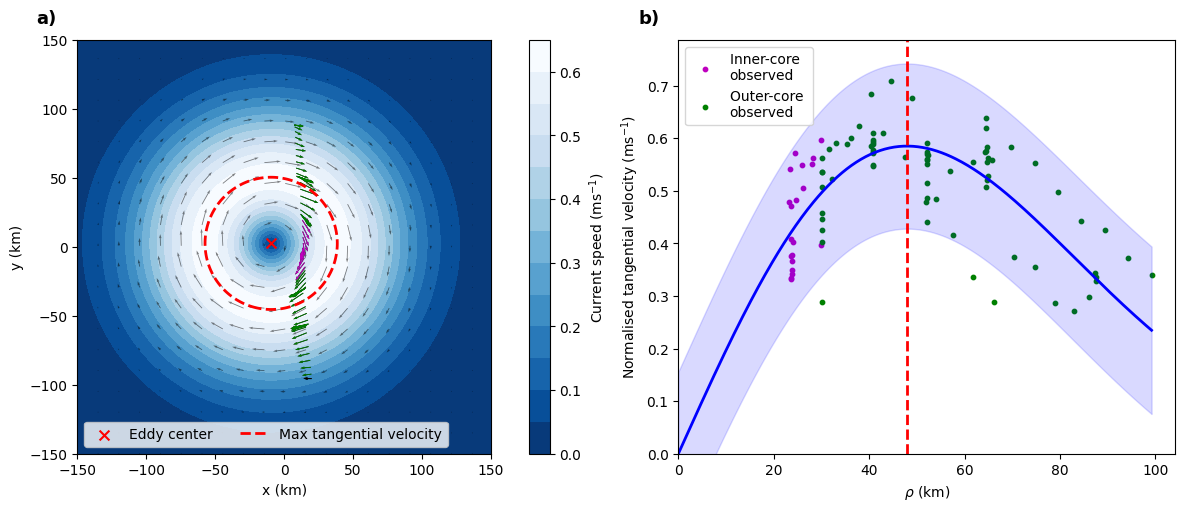

In [7]:
u = ds_model.u
v = ds_model.v
speed = np.hypot(u, v)

# 1D km coords for plotting
x = (ds_model.x / 1e3).values
y = (ds_model.y / 1e3).values

xmin, xmax = -150, 150
ymin, ymax = -150, 150

# 2D ROI mask (ny, nx)
Xkm, Ykm = np.meshgrid(x, y, indexing="xy")
roi = (Xkm >= xmin) & (Xkm <= xmax) & (Ykm >= ymin) & (Ykm <= ymax)

speed_m = speed.where(roi)

vmin = float(speed_m.min(skipna=True))
vmax = float(speed_m.max(skipna=True))
levels = np.arange(0, vmax+.05, .05)

fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

ax = axs[0]

# field first (so vectors on top)
cf = ax.contourf(x, y, speed_m.values, levels=levels, cmap="Blues_r", vmin=vmin, vmax=vmax, zorder=-1)
fig.colorbar(cf, ax=ax, label=r"Current speed (ms$^{-1}$)")

spac, scale = 10, 15
ax.quiver(x[::spac], y[::spac],
              u[::spac,::spac], v[::spac,::spac],
              scale=scale, alpha=.5, width=.002)

# SADCP vectors (x,y already metres -> convert to km; u,v are m/s)
ax.quiver(ds_sadcp.x.values/1e3, ds_sadcp.y.values/1e3,
          ds_sadcp.u.values, ds_sadcp.v.values,
          width=.002, scale=scale)

R = np.hypot(data.xc - ds_sadcp.x.values, data.yc - ds_sadcp.y.values)

core_mask  = R <= 30_000
outer_mask = (R > 30_000) & (R <= 100_000)

ax.quiver(ds_sadcp.x.values[core_mask]/1e3, ds_sadcp.y.values[core_mask]/1e3,
          ds_sadcp.u.values[core_mask], ds_sadcp.v.values[core_mask],
          width=.002, scale=scale, color='m')#, label='Core data')

ax.quiver(ds_sadcp.x.values[outer_mask]/1e3, ds_sadcp.y.values[outer_mask]/1e3,
          ds_sadcp.u.values[outer_mask], ds_sadcp.v.values[outer_mask],
          width=.002, scale=scale, color='g')#, label='Outer-core \ndata') 

# center
ax.scatter(xc/1e3, yc/1e3, marker="x", color="r", s=50, label='Eddy center')

# ellipse contour: compute in metres, but evaluate on the km grid
Xm = Xkm * 1e3
Ym = Ykm * 1e3
dx = Xm - xc
dy = Ym - yc
rho2 = Q[0,0]*dx*dx + 2*Q[0,1]*dx*dy + Q[1,1]*dy*dy

ax.contour(x, y, rho2, levels=[(Rc**2)/2], colors="r", linewidths=2, linestyles='--')
ax.plot([np.nan, np.nan], [np.nan, np.nan], color='r', ls='--', lw=2, label='Max tangential velocity')

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.legend(loc='lower left', ncol=2)
ax.text(-0.10, 1.04, 'a)', transform=ax.transAxes, fontsize=13, fontweight='bold')

ax = axs[1]
out_core_param_fit(rho2_f/1e6, Qr_f/1e3, vt_f, Omega0=Omega,  ax=ax, plot=True, km_flag=True, pred_flag=True)


ax.set_title(''); ax.set_xlabel(r'$\rho$ (km)'); ax.set_ylabel(r'Normalised tangential velocity (ms$^{-1}$)');
ax.text(-0.08, 1.04, 'b)', transform=ax.transAxes, fontsize=13, fontweight='bold')

plt.show()


In [8]:
df_res


,xc,yc,w,Q,alpha,Rc,psi0,Omega,time,R2
0,-9434.63993,2507.191384,-0.00004,"[[1.0, 0.0], [0.0, 1.0]]",1,67805.07156,46249.456752,-0.000021,2023-10-18 01:35:00.562501248,0.943559
